# Project: Credit Classification

This project is divided into Four Parts. The first three belong to the midcourse project, and the last will be completed in the final project.

1. Data Prep & EDA
2. Logistic Regression
3. Imbalanced Data
4. Ensemble Models



## Step 1: Data Prep & EDA

1. Import the data - perform any datatype conversion as necessary
2. Modify the target variable - Group 'Standard' and 'Good' Credit together to create a binary classification problem
3. Explore the Data - which features appear to impact credit score group the most? Are any features highly correlated with each other? Remove any unnecessary features.
4. Prepare your data for modelling. Create dummy variables, split your data into train and test, and scale your features if necessary.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

credit_df = pd.read_csv("../Data/credit_train_clean.csv").drop(["Name", "SSN", "ID", "Customer_ID"], axis=1)

credit_df.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,1,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",...,Good,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,2,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",...,Good,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good
2,3,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",...,Good,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,4,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",...,Good,809.98,31.377862,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",...,Good,809.98,24.797347,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


In [3]:
credit_df.dtypes

Month                         int64
Age                         float64
Occupation                   object
Annual_Income               float64
Monthly_Inhand_Salary       float64
Num_Bank_Accounts           float64
Num_Credit_Card             float64
Interest_Rate               float64
Num_of_Loan                 float64
Type_of_Loan                 object
Delay_from_due_date         float64
Num_of_Delayed_Payment      float64
Changed_Credit_Limit        float64
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt            float64
Credit_Utilization_Ratio    float64
Credit_History_Age          float64
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Payment_Behaviour            object
Monthly_Balance             float64
Credit_Score                 object
dtype: object

In [27]:
credit_df["Credit_Score"].value_counts()

Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64

In [2]:
credit_df["Credit_Score"]=np.where((credit_df["Credit_Score"]=="Standard") | (credit_df["Credit_Score"]=="Good"),"Good or Standard","Poor")

In [9]:
credit_df["Credit_Score"].value_counts()

Credit_Score
Good or Standard    71002
Poor                28998
Name: count, dtype: int64

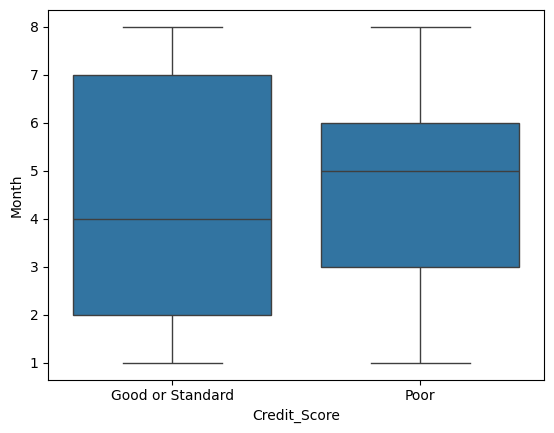

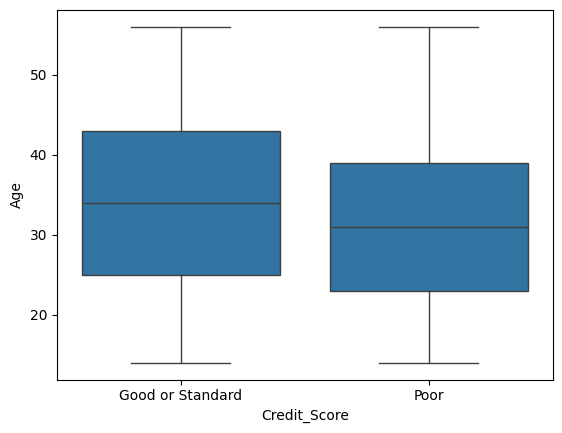

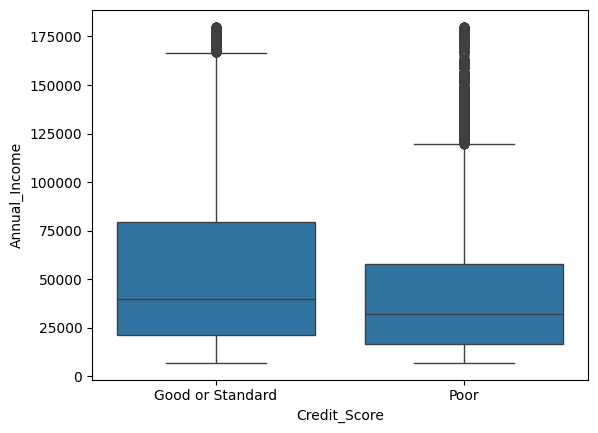

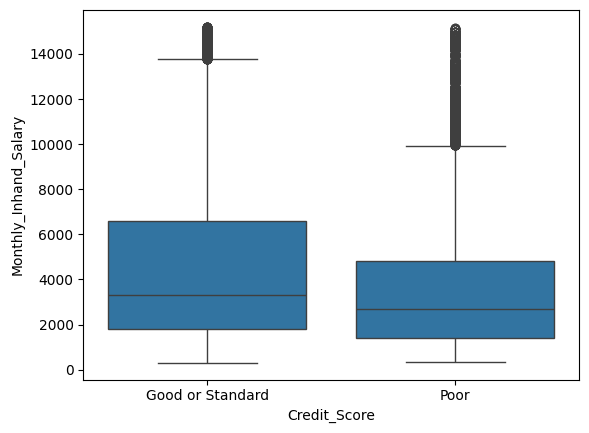

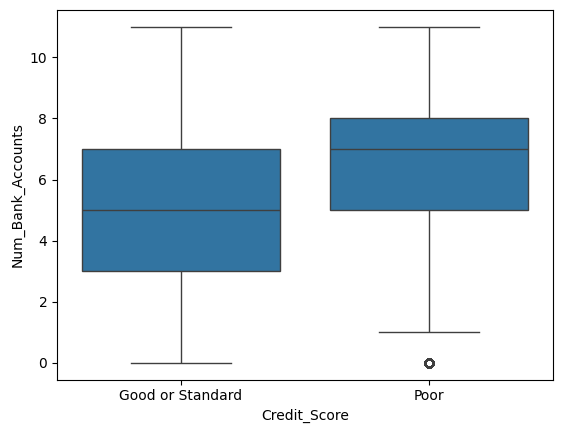

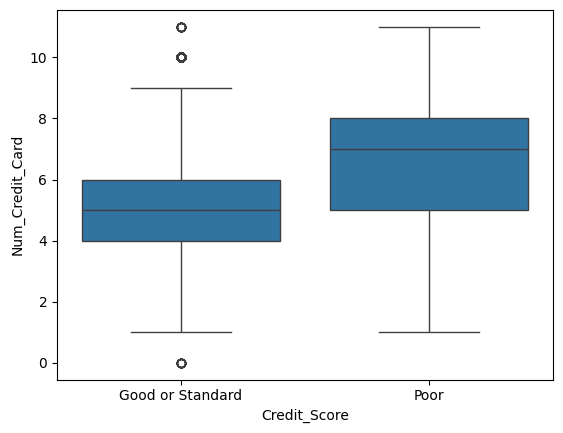

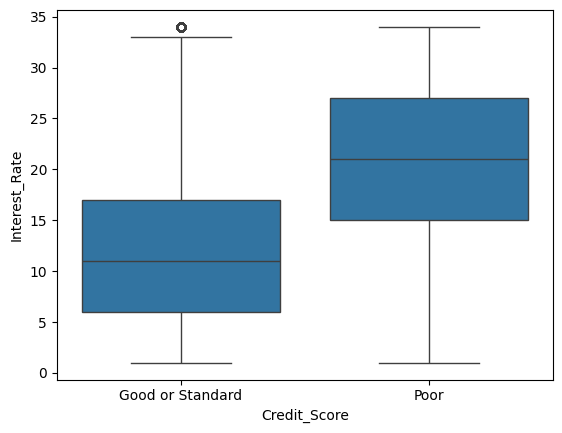

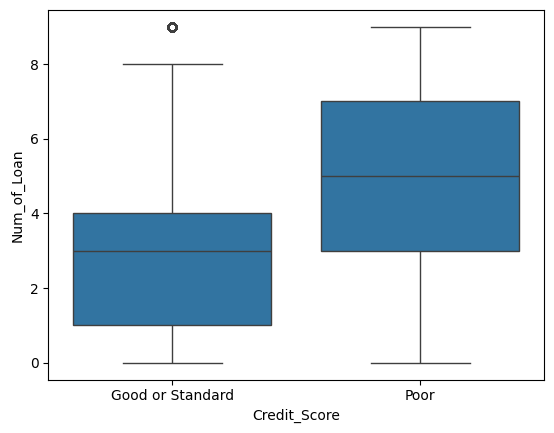

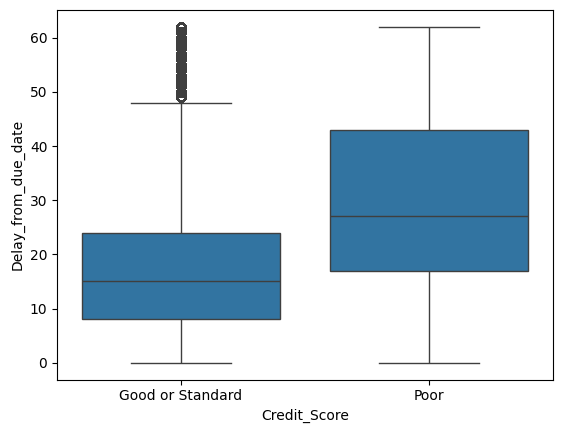

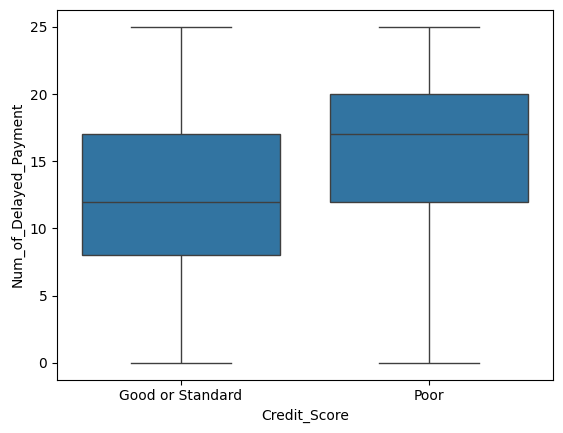

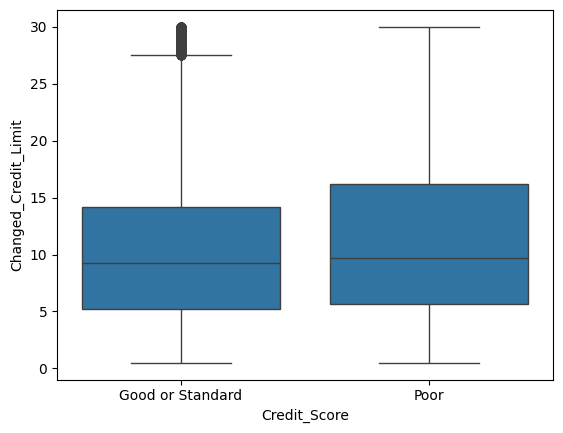

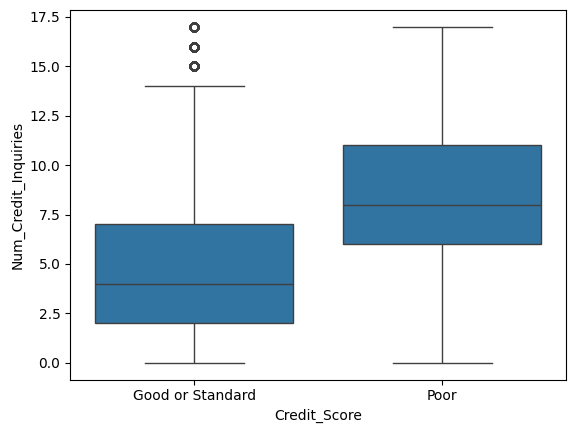

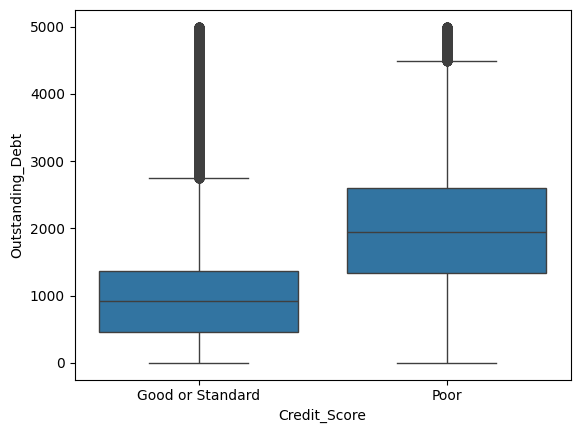

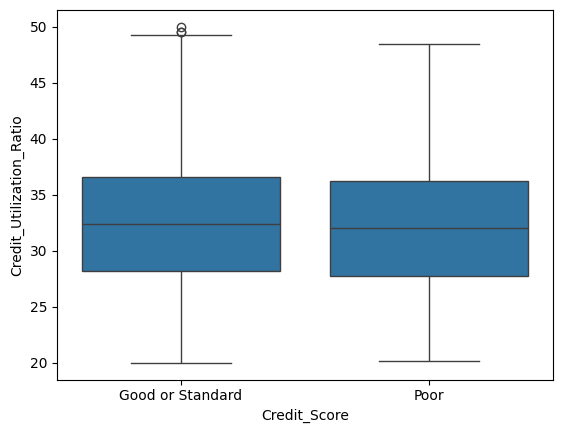

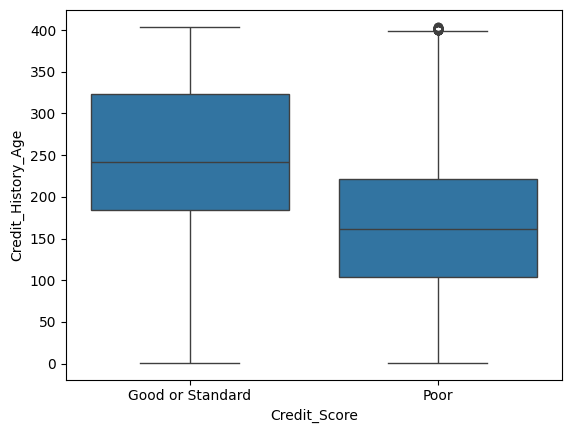

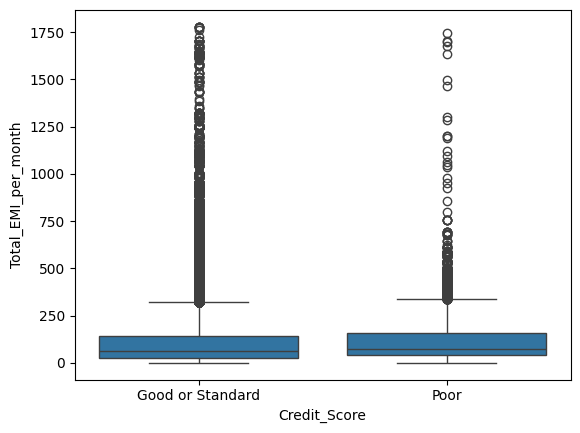

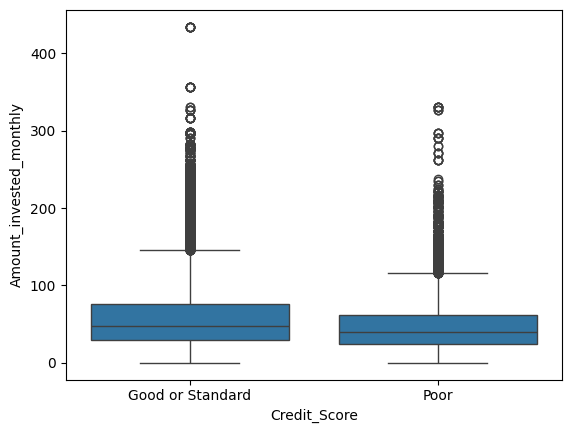

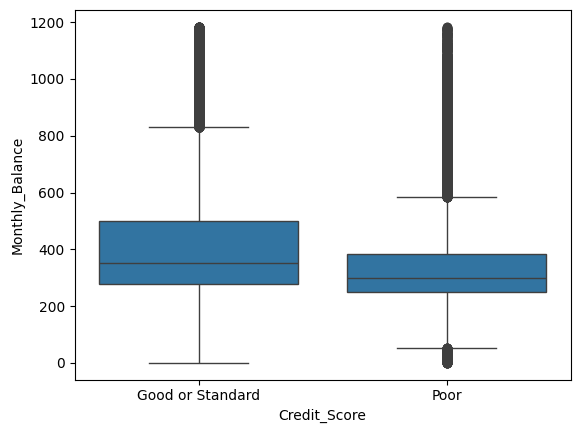

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
for numbers in credit_df.select_dtypes("number"):
    sns.boxplot(data=credit_df,y=numbers,x="Credit_Score")
    plt.show()

In [3]:
credit_df["Credit_Score"]=np.where(credit_df["Credit_Score"]=="Good or Standard",1,0)

In [5]:
credit_df.groupby("Occupation")["Credit_Score"].mean()

Occupation
Accountant       0.697954
Architect        0.728165
Developer        0.713690
Doctor           0.725335
Engineer         0.694930
Entrepreneur     0.694194
Journalist       0.718482
Lawyer           0.723083
Manager          0.711443
Mechanic         0.698347
Media_Manager    0.737500
Musician         0.718829
Scientist        0.694247
Teacher          0.696193
Writer           0.697494
Name: Credit_Score, dtype: float64

In [6]:
pd.DataFrame(credit_df.groupby("Occupation")["Credit_Score"].mean()).reset_index()

,Occupation,Credit_Score
0,Accountant,0.697954
1,Architect,0.728165
2,Developer,0.713690
3,Doctor,0.725335
4,Engineer,0.694930
5,Entrepreneur,0.694194
6,Journalist,0.718482
7,Lawyer,0.723083
8,Manager,0.711443
9,Mechanic,0.698347


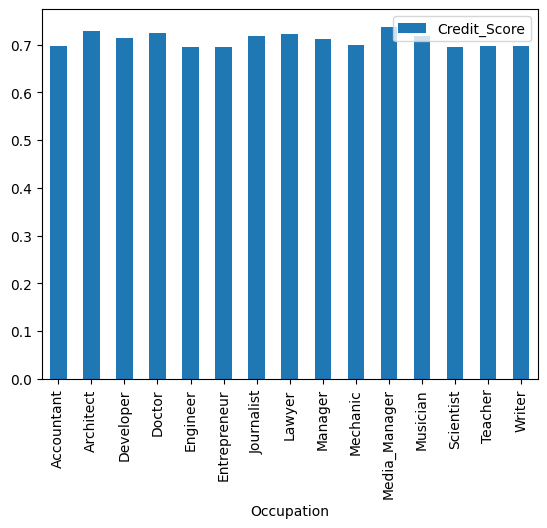

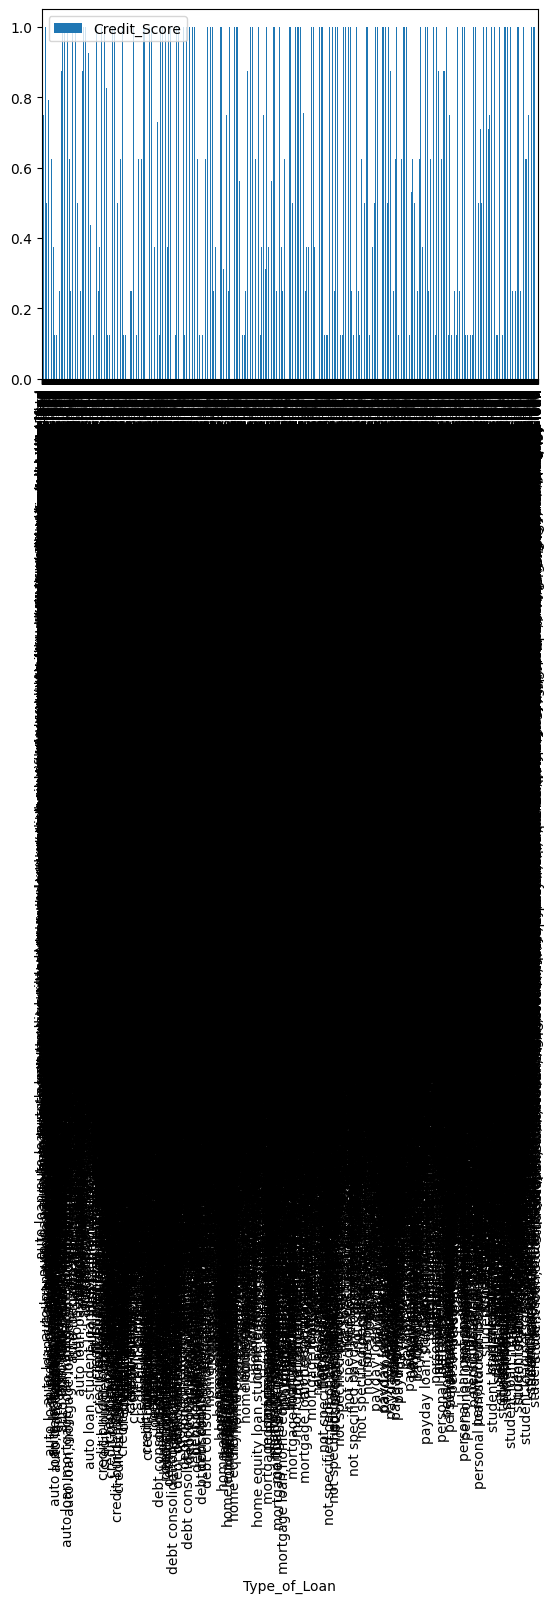

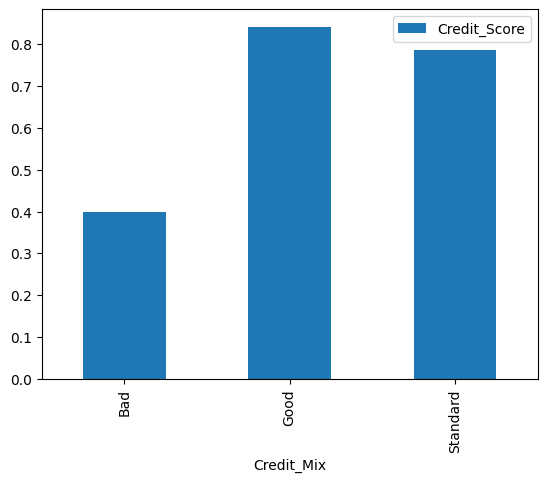

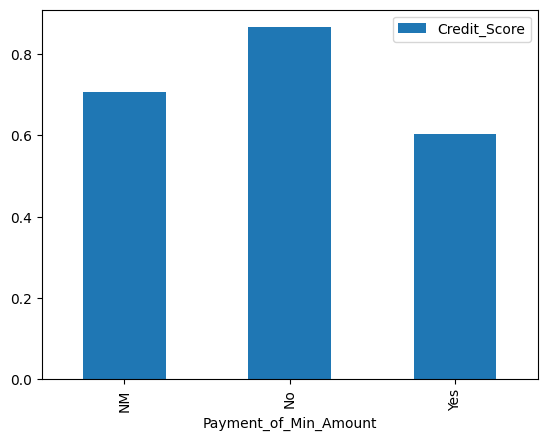

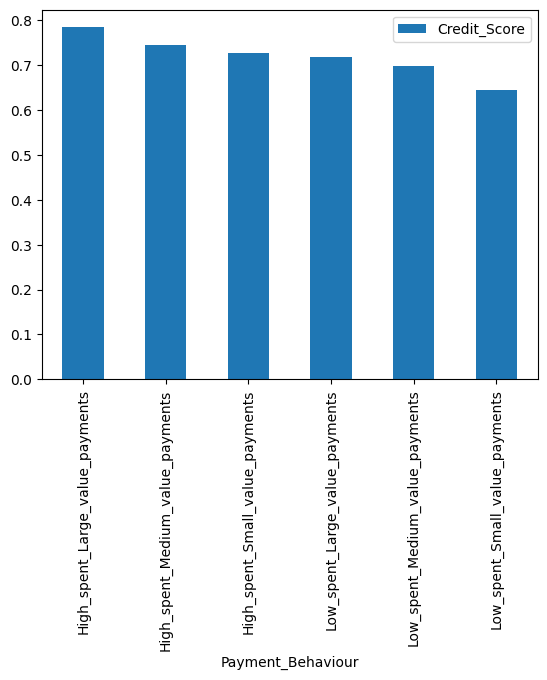

In [9]:
import seaborn as sns
for numbers in credit_df.select_dtypes("object"):
    pd.DataFrame(credit_df.groupby(numbers)["Credit_Score"].mean()).reset_index().plot.bar(x=numbers,y="Credit_Score")
    plt.show()

In [14]:
credit_df.select_dtypes("number").corr()

,Month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_Score
Month,1.000000e+00,0.016990,1.530483e-17,-0.001819,0.000079,0.000090,6.790115e-18,1.555542e-16,0.000342,0.000115,-0.000671,0.139604,3.200578e-17,0.002440,0.022784,0.049716,-1.043065e-16,-0.002095,-0.005232
Age,1.698955e-02,1.000000,9.152456e-02,0.090636,-0.190415,-0.148567,-2.175571e-01,-2.135330e-01,-0.174119,-0.184264,-0.157254,-0.250960,-2.023741e-01,0.025492,0.234618,-0.047334,7.104515e-02,0.116098,0.125963
Annual_Income,1.530483e-17,0.091525,1.000000e+00,0.998154,-0.284060,-0.217852,-3.023524e-01,-2.555596e-01,-0.250105,-0.286297,-0.176353,-0.280242,-2.693193e-01,0.175930,0.272374,0.438106,8.062806e-01,0.625640,0.165538
Monthly_Inhand_Salary,-1.818625e-03,0.090636,9.981538e-01,1.000000,-0.283181,-0.216847,-3.018580e-01,-2.542982e-01,-0.249438,-0.285360,-0.176187,-0.279736,-2.690445e-01,0.176092,0.271457,0.421836,8.073264e-01,0.626631,0.163800
Num_Bank_Accounts,7.909795e-05,-0.190415,-2.840602e-01,-0.283181,1.000000,0.442694,5.843015e-01,4.724831e-01,0.560193,0.601842,0.333794,0.518323,5.070634e-01,-0.071783,-0.485331,0.050035,-2.278278e-01,-0.286709,-0.285344
Num_Credit_Card,8.973261e-05,-0.148567,-2.178520e-01,-0.216847,0.442694,1.000000,4.979115e-01,4.179595e-01,0.479762,0.423300,0.255495,0.459429,4.903760e-01,-0.055249,-0.417205,0.058853,-1.746004e-01,-0.231913,-0.337477
Interest_Rate,6.790115e-18,-0.217557,-3.023524e-01,-0.301858,0.584302,0.497912,1.000000e+00,5.591562e-01,0.589185,0.571457,0.370156,0.632562,6.294144e-01,-0.075700,-0.576230,0.071651,-2.424790e-01,-0.317919,-0.413436
Num_of_Loan,1.555542e-16,-0.213533,-2.555596e-01,-0.254298,0.472483,0.417960,5.591562e-01,1.000000e+00,0.501599,0.473919,0.374602,0.565087,6.387126e-01,-0.100469,-0.605727,0.328485,-2.142544e-01,-0.429416,-0.319454
Delay_from_due_date,3.418202e-04,-0.174119,-2.501051e-01,-0.249438,0.560193,0.479762,5.891847e-01,5.015994e-01,1.000000,0.541627,0.296571,0.539919,5.722057e-01,-0.063823,-0.491484,0.078820,-2.017369e-01,-0.272273,-0.373285
Num_of_Delayed_Payment,1.154567e-04,-0.184264,-2.862966e-01,-0.285360,0.601842,0.423300,5.714569e-01,4.739186e-01,0.541627,1.000000,0.329311,0.499689,5.040191e-01,-0.073774,-0.481965,0.053653,-2.284590e-01,-0.286045,-0.255824


In [5]:
from sklearn.model_selection import train_test_split
def split_data(data):
    target = data["Credit_Score"]
    features = data.drop(columns={"Credit_Score","Type_of_Loan"})
    features = pd.get_dummies(features,drop_first=True)
    X_train,X_test,y_train,y_test = train_test_split(features,target,test_size=0.2, random_state=42)
    return X_train,X_test,y_train,y_test
X_train,X_test,y_train,y_test = split_data(credit_df)

## Step 2: Logistic Regression

1. Fit a Logistic Regression Model that uses default hyperparameters.
2. Tune the hyperparameters of your logistic regression model
3. Report accuracy, precision, recall & F1 score after tuning your threshold to maximize F1 Score
4. Plot the ROC curve and report AUC for your tuned model

In [29]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr_fit = lr.fit(X_train,y_train)
print(lr_fit.score(X_train,y_train))
print(lr_fit.score(X_test,y_test))

0.7633125
0.759


c:\Users\Eli\miniforge3\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
lr_gs = LogisticRegression(max_iter=1000)

parameters = {'penalty':['l1','l2','elasticnet'],
              'C':[.2,.5,.9],
              'solver':['saga']
              }
gs = GridSearchCV(lr_gs,param_grid=parameters)
gs.fit(X_train_scaled,y_train)
print(gs.best_params_)

KeyboardInterrupt: 

In [37]:
lr_best = LogisticRegression(**gs.best_params_)
lr_best_fit = lr_best.fit(X_train_scaled,y_train)
print(lr_best_fit.score(X_train_scaled,y_train))
print(lr_best_fit.score(X_test_scaled,y_test))

0.78895
0.78685


In [60]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

thresholds = np.arange(start=0,stop=1.1,step=.1)
f1_scores=[]
for threshold in thresholds:
    f1_scores.append(f1_score(y_test,lr_best_fit.predict_proba(X_test_scaled)[:,1]>threshold))
pd.DataFrame(f1_scores)


,0
0,0.827873
1,0.829617
2,0.836448
3,0.845302
4,0.852681
5,0.855887
6,0.856491
7,0.838923
8,0.768750
9,0.454818


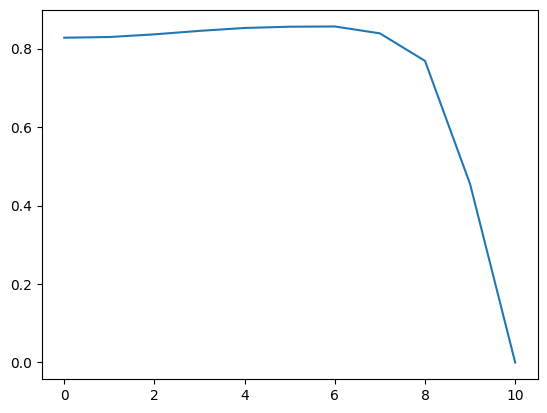

In [61]:
plt.plot(f1_scores)

In [92]:
print("accuracy score: " + str(accuracy_score(y_test,lr_best_fit.predict_proba(X_test_scaled)[:,1]>.6)))
print("precision score: " + str(precision_score(y_test,lr_best_fit.predict_proba(X_test_scaled)[:,1]>.6)))
print("recall score: " + str(recall_score(y_test,lr_best_fit.predict_proba(X_test_scaled)[:,1]>.6)))
print("f1 score: " + str(f1_score(y_test,lr_best_fit.predict_proba(X_test_scaled)[:,1]>.6)))

accuracy score: 0.7956
precision score: 0.8495125348189415
recall score: 0.8635848789466233
f1 score: 0.856490907814365


auc score: 0.8198046826096625


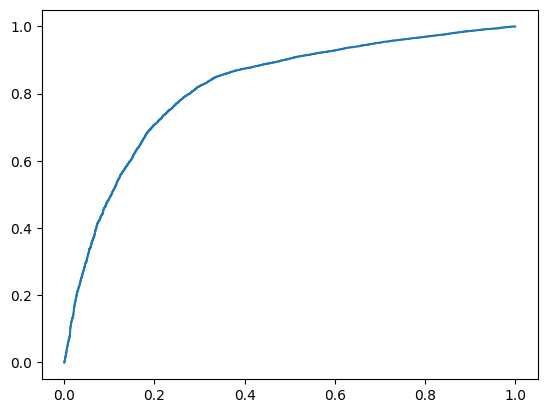

In [79]:
from sklearn.metrics import roc_curve,auc
y_probs = lr_best_fit.predict_proba(X_test_scaled)[:,1]
fpr,tpr,threshold = roc_curve(y_test,y_probs)
plt.plot(fpr[:-1],tpr[:-1])
print("auc score: "+str(auc(fpr,tpr)))

## Step 3. Imbalanced Data Techniques

1. Try using SMOTE, by resampling up to an equal number of 0s and 1s, then tune your model threshold. 
2. Did this improve your model performance in terms of accuracy, F1, and AUC?

In [87]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy="auto",random_state=0)
X_train_balanced,y_train_balanced = smote.fit_resample(X_train_scaled,y_train)
lr_smote = LogisticRegression(**gs.best_params_,max_iter=1000)
lr_smote_fit = lr_smote.fit(X_train_balanced,y_train_balanced)

In [88]:
y_train_balanced.value_counts()

Credit_Score
1    56876
0    56876
Name: count, dtype: int64

In [89]:
thresholds = np.arange(start=0,stop=1.1,step=.1)
f1_scores=[]
for threshold in thresholds:
    f1_scores.append(f1_score(y_test,lr_smote_fit.predict_proba(X_test_scaled)[:,1]>threshold))
pd.DataFrame(f1_scores)

,0
0,0.827873
1,0.837666
2,0.851162
3,0.854096
4,0.853023
5,0.835096
6,0.791716
7,0.686741
8,0.470332
9,0.131234


In [94]:
y_probs = (lr_smote_fit.predict_proba(X_test_scaled)[:,1]>.3)
print("accuracy score: " + str(accuracy_score(y_test,y_probs)))
print("precision score: " + str(precision_score(y_test,y_probs)))
print("recall score: " + str(recall_score(y_test,y_probs)))
print("f1 score: " + str(f1_score(y_test,y_probs)))

accuracy score: 0.7859
precision score: 0.8233477860990671
recall score: 0.8872292227098967
f1 score: 0.8540956794330108


## Step 4: Ensemble Models

1. Fit & Tune Random Forest and GBM Models
2. Plot the ROC curves for both models
3. Select the model with the best AUC, then tune the threshold to maximize f1, and report final metrics
4. Build a Beeswarm plot of shap values for your final model.

In [95]:
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
rf = RandomForestClassifier()
gb = GradientBoostingClassifier()
rf_fit = rf.fit(X_train_scaled,y_train)
gb_fit = gb.fit(X_train_scaled,y_train)


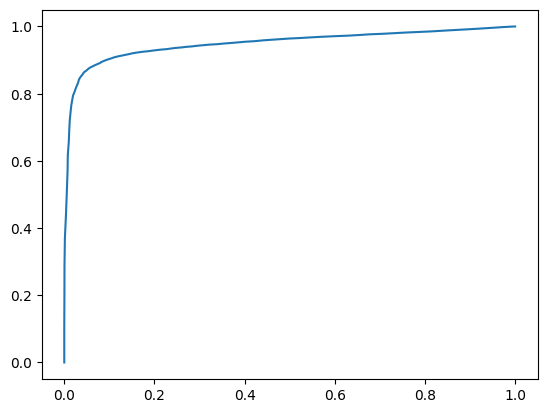

In [109]:
tpr,fpr,threadhold=roc_curve(y_test,rf_fit.predict_proba(X_test_scaled)[:,1])
plt.plot(tpr,fpr)

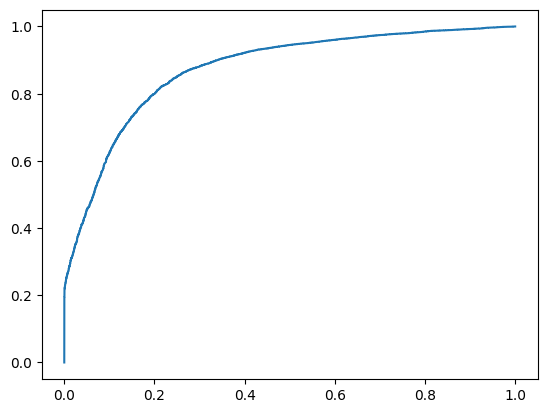

In [110]:
tpr,fpr,threadhold=roc_curve(y_test,gb_fit.predict_proba(X_test_scaled)[:,1])
plt.plot(tpr,fpr)

In [98]:
fpr,tpr,threshold = roc_curve(y_test,rf_fit.predict_proba(X_test_scaled)[:,1])
print("random forest AUC:"+str(auc(fpr,tpr)))
fpr,tpr,threshold = roc_curve(y_test,gb_fit.predict_proba(X_test_scaled)[:,1])
print("gradient boosting AUC:"+str(auc(fpr,tpr)))

random forest AUC:0.9490459809860484
gradient boosting AUC:0.873764186671337


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
rf_best = RandomForestClassifier(random_state=0)
paramters = {"n_estimators":[20,50,75,100],
             "max_depth":[2,5,10],
             "min_samples_leaf": [2,5,10],
             "bootstrap":[True,False],
             "max_features": ["sqrt"],
             "max_samples":[.3,.6,.9]
             }
random_search = RandomizedSearchCV(estimator=rf_best, param_distributions=parameters, n_iter=10, random_state=0)
random_search.fit(X_train_scaled,y_train)
random_search.best_params_

{'n_estimators': 50,
 'min_samples_split': 10,
 'max_samples': 0.8,
 'max_features': 'sqrt',
 'max_depth': 10}

In [111]:
thresholds = np.arange(start=0,stop=1.1,step=.1)
f1_scores=[]
for threshold in thresholds:
    f1_scores.append(f1_score(y_test,random_search.predict_proba(X_test_scaled)[:,1]>threshold))
pd.DataFrame(f1_scores)

,0
0,0.827873
1,0.827873
2,0.833664
3,0.874492
4,0.884857
5,0.888028
6,0.875992
7,0.853353
8,0.834504
9,0.591782


In [112]:
y_probs = (random_search.predict_proba(X_test_scaled)[:,1]>.5)
print("accuracy score: " + str(accuracy_score(y_test,y_probs)))
print("precision score: " + str(precision_score(y_test,y_probs)))
print("recall score: " + str(recall_score(y_test,y_probs)))
print("f1 score: " + str(f1_score(y_test,y_probs)))

accuracy score: 0.8352
precision score: 0.8536903984323971
recall score: 0.9252442304969559
f1 score: 0.8880282647098791


In [10]:
params = {'n_estimators': 50,
 'min_samples_split': 10,
 'max_samples': 0.8,
 'max_features': 'sqrt',
 'max_depth': 10}

In [24]:
X_test.shape

(20000, 41)

In [28]:
import shap
rf_best_fit = RandomForestClassifier(**params,random_state=0)
rf_best_fit.fit(X_train_scaled,y_train)
explainer = shap.Explainer(rf_best_fit)
shap_values = explainer(pd.DataFrame(X_test_scaled).sample(80,random_state=0))
shap_df = pd.DataFrame(shap_values.values[:,:,1],columns=X_test.columns)
shap_df.head()


,Month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Occupation_Writer,Credit_Mix_Good,Credit_Mix_Standard,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments
0,0.013983,0.004475,0.001193,0.001029,0.010636,0.003602,0.066347,0.007417,0.015776,0.000663,...,0.000457,0.008318,0.039678,-0.001815,-0.007292,-0.000204,0.000985,0.000010,0.000219,0.001618
1,-0.001883,0.011905,0.005401,0.003384,0.011117,-0.003485,0.048568,0.004729,-0.059314,0.014920,...,0.000613,-0.005606,-0.050537,0.000227,-0.001206,0.000337,-0.000249,-0.000110,0.000284,0.001533
2,-0.014671,0.002808,-0.004701,-0.001726,-0.011709,-0.105349,-0.006742,-0.029710,-0.002111,-0.021561,...,0.000095,-0.016230,-0.053163,-0.009914,-0.011292,0.001362,-0.000149,-0.000095,0.000103,0.002293
3,-0.008087,0.000138,0.002026,0.002078,0.007957,0.021010,0.081334,0.003550,-0.012334,-0.002679,...,0.000152,0.010116,0.044695,-0.000855,-0.004174,-0.000322,-0.000183,-0.000006,-0.002583,0.003456
4,-0.014743,-0.001655,-0.004829,-0.005835,-0.008634,0.000879,-0.155465,-0.003921,-0.101270,0.004134,...,0.000086,-0.007533,0.007309,-0.007762,-0.007113,-0.000674,-0.000368,0.000052,0.000147,-0.003572


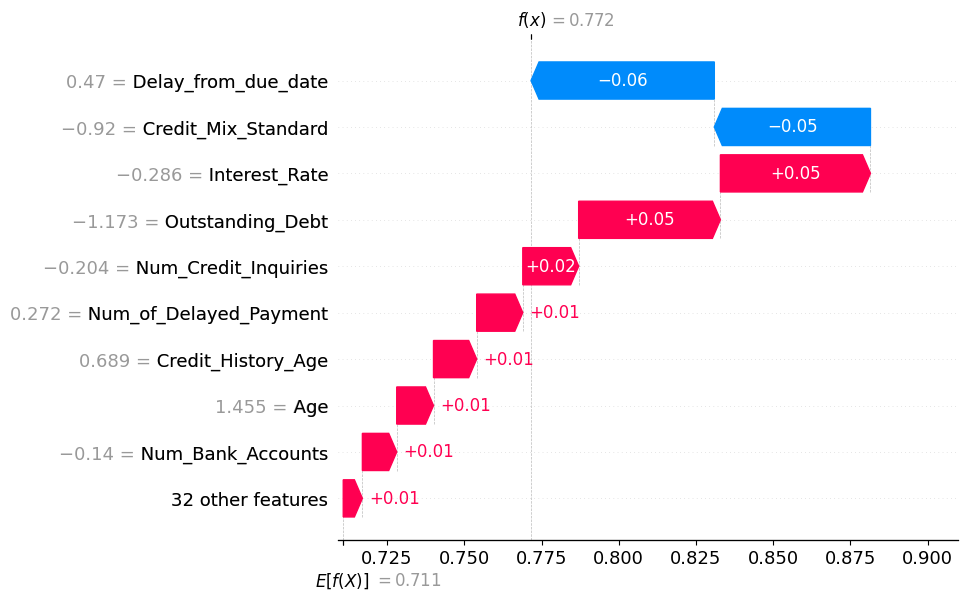

In [45]:
shap_values.feature_names = X_test.columns.tolist()
shap.plots.waterfall(shap_values[1,:,1])

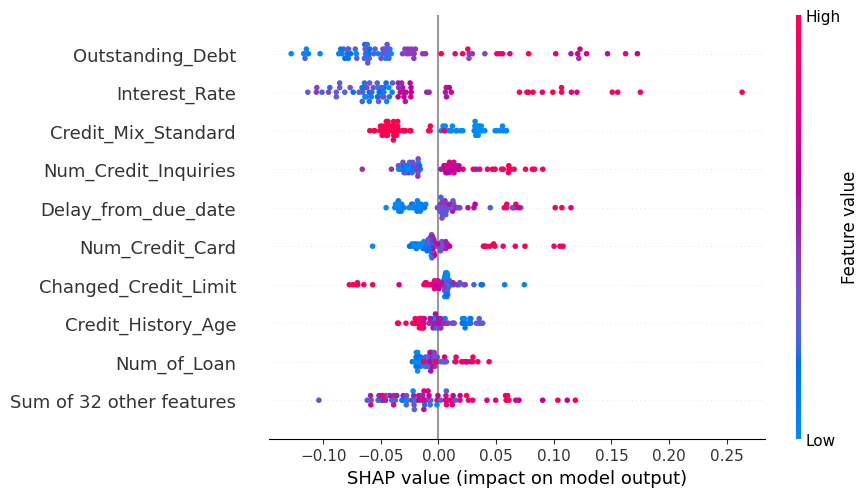

In [47]:
shap.plots.beeswarm(shap_values[:,:,0])